In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import RFE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names

print("Dataset Shape:", X.shape)
print("Total Features:", X.shape[1])

Dataset Shape: (569, 30)
Total Features: 30


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [5]:
feature_numbers = [20, 15, 10, 5, 2]

results = []

print("Feature numbers:", feature_numbers)

Feature numbers: [20, 15, 10, 5, 2]


In [6]:
for n in feature_numbers:

    print("\n-----------------------------")
    print("Number of Features:", n)

    start_time = time.time()

    selector = RFE(
        estimator=SVC(kernel="linear"),
        n_features_to_select=n
    )

    X_train_selected = selector.fit_transform(
        X_train_scaled, y_train
    )

    X_test_selected = selector.transform(
        X_test_scaled
    )

    model = SVC(kernel="linear")

    model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_test_selected)

    end_time = time.time()

    execution_time = end_time - start_time

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test, y_pred, pos_label=0
    )

    recall = recall_score(
        y_test, y_pred, pos_label=0
    )

    f1 = f1_score(
        y_test, y_pred, pos_label=0
    )

    selected_features = feature_names[
        selector.support_
    ]

    print("Selected Features:")
    print(selected_features)

    print("Accuracy:", accuracy * 100, "%")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Execution Time:", execution_time, "seconds")

    results.append({
        "Features": n,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Execution Time": execution_time
    })


-----------------------------
Number of Features: 20
Selected Features:
['mean radius' 'mean perimeter' 'mean area' 'mean compactness'
 'mean concavity' 'mean concave points' 'radius error' 'texture error'
 'perimeter error' 'area error' 'compactness error' 'concave points error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst concavity' 'worst concave points'
 'worst symmetry']
Accuracy: 96.49122807017544 %
Precision: 0.9318181818181818
Recall: 0.9761904761904762
F1 Score: 0.9534883720930233
Execution Time: 0.062439680099487305 seconds

-----------------------------
Number of Features: 15
Selected Features:
['mean radius' 'mean perimeter' 'mean area' 'mean compactness'
 'mean concavity' 'radius error' 'perimeter error' 'area error'
 'worst radius' 'worst texture' 'worst area' 'worst smoothness'
 'worst concavity' 'worst concave points' 'worst symmetry']
Accuracy: 95.6140350877193 %
Precision: 0.9302325581395349
Recall: 0.9523809523809523
F1 S

In [7]:
df = pd.DataFrame(results)

print("REDUCED FEATURES COMPARISON")

print(df.to_string(index=False))

REDUCED FEATURES COMPARISON
 Features  Accuracy  Precision   Recall  F1 Score  Execution Time
       20  0.964912   0.931818 0.976190  0.953488        0.062440
       15  0.956140   0.930233 0.952381  0.941176        0.083027
       10  0.947368   0.909091 0.952381  0.930233        0.108343
        5  0.947368   0.928571 0.928571  0.928571        0.168348
        2  0.938596   0.888889 0.952381  0.919540        0.214259


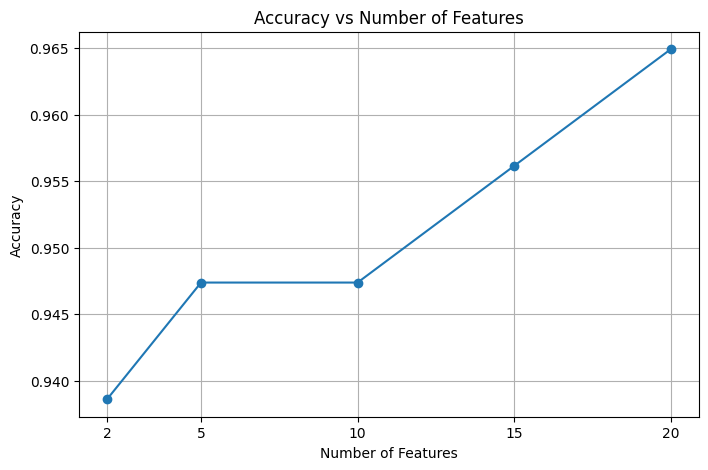

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["Features"],
    df["Accuracy"],
    marker="o"
)

plt.title("Accuracy vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")

plt.xticks(feature_numbers)

plt.grid(True)

plt.show()

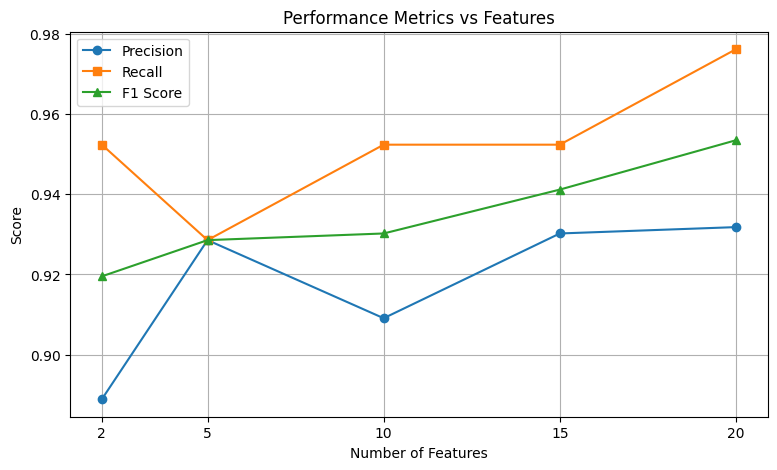

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(
    df["Features"],
    df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    df["Features"],
    df["Recall"],
    marker="s",
    label="Recall"
)

plt.plot(
    df["Features"],
    df["F1 Score"],
    marker="^",
    label="F1 Score"
)

plt.title("Performance Metrics vs Features")

plt.xlabel("Number of Features")
plt.ylabel("Score")

plt.xticks(feature_numbers)

plt.legend()
plt.grid(True)

plt.show()

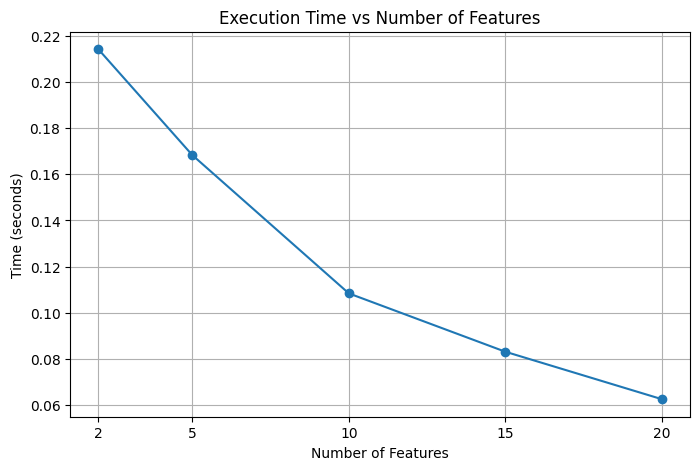

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["Features"],
    df["Execution Time"],
    marker="o"
)

plt.title("Execution Time vs Number of Features")

plt.xlabel("Number of Features")
plt.ylabel("Time (seconds)")

plt.xticks(feature_numbers)

plt.grid(True)

plt.show()